# 02 — Trade-off de estabilidade dos três métodos

## Resumo

Este experimento completa a comparação entre o gerador AST original, a modificação que multiplica cada folha `LAG` por um coeficiente e o gerador AR estacionário por construção. Os três métodos são submetidos à mesma inicialização nula, às mesmas inovações gaussianas, aos mesmos horizontes e às mesmas regras operacionais de explosão e cauda próxima de zero. O método estacionário também é avaliado com sua inicialização nativa exata, sorteada da distribuição invariante. Medimos frequência de explosão, frequência de cauda próxima de zero, resultados intermediários, throughput de amostragem e throughput de execução. A comparação operacional quantifica o comportamento das implementações; a garantia do terceiro método vem separadamente das raízes do polinômio AR, e não da ausência de eventos extremos em uma amostra finita.

## 1. Desenho da comparação

O protocolo principal fixa o histórico inicial em zero. Isso isola melhor a dinâmica das recorrências. O protocolo adicional usa apenas o método estacionário e conserva sua propriedade de começar diretamente na distribuição estacionária. As ASTs original e coefficient-gated podem conter produtos entre lags; a família estacionária implementada aqui é AR linear e usa todos os lags consecutivos até a ordem sorteada. Portanto, os resultados medem três geradores disponíveis, mas não transformam suas famílias de fórmulas em equivalentes.

In [1]:
from __future__ import annotations

from dataclasses import asdict, replace
from pathlib import Path
import importlib.metadata
import json
import platform
import subprocess
import sys
import time

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'tsfmxai').exists():
            return candidate
    raise RuntimeError('Repository root not found.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_ROOT = PROJECT_ROOT / 'src'
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from tsfmxai.evaluation import (
    StabilityDiagnosticConfig,
    diagnose_stability_prefixes,
    wilson_interval,
)
from tsfmxai.generators import (
    RandomTreeConfig,
    StationaryARConfig,
    evaluate_bound_expression,
    required_history_length,
    sample_random_mechanisms,
    sample_stationary_ar_mechanisms,
)

ROOT_SEED = 20261001
SAMPLE_COUNT = 5_000
HORIZONS = (96, 192, 384)
REFERENCE_HORIZON = 192
INNOVATION_STD = 0.05
EXPLOSION_LIMIT = 100.0
NEAR_ZERO_RADIUS = 3.0 * INNOVATION_STD
NEAR_ZERO_TAIL_STEPS = 24

DIAGNOSTIC_CONFIG = StabilityDiagnosticConfig(
    horizons=HORIZONS,
    explosion_limit=EXPLOSION_LIMIT,
    near_zero_radius=NEAR_ZERO_RADIUS,
    near_zero_tail_steps=NEAR_ZERO_TAIL_STEPS,
)
BASE_CONFIG = RandomTreeConfig(
    minimum_operators=1, maximum_operators=6, num_series=1,
    minimum_lag=1, maximum_lag=12, parameter_probability=0.55,
    time_probability=0.0, lag_probability=0.45, add_probability=0.80,
    minimum_parameter_magnitude=0.05, maximum_parameter_magnitude=0.80,
    require_lag=True, require_time=False, coefficient_gate_lags=False,
)
GATED_CONFIG = replace(BASE_CONFIG, coefficient_gate_lags=True)
STATIONARY_CONFIG = StationaryARConfig(
    minimum_order=1, maximum_order=12,
    partial_autocorrelation_minimum=-0.80,
    partial_autocorrelation_maximum=0.80,
    mean_minimum=0.0, mean_maximum=0.0,
    innovation_std_minimum=INNOVATION_STD,
    innovation_std_maximum=INNOVATION_STD,
)

configuration = {
    'root_seed': ROOT_SEED, 'sample_count_per_method': SAMPLE_COUNT,
    'horizons': list(HORIZONS), 'reference_horizon': REFERENCE_HORIZON,
    'innovation_std': INNOVATION_STD, 'explosion_limit': EXPLOSION_LIMIT,
    'near_zero_radius': NEAR_ZERO_RADIUS,
    'near_zero_tail_steps': NEAR_ZERO_TAIL_STEPS,
    'baseline_tree_config': asdict(BASE_CONFIG),
    'gated_tree_config': asdict(GATED_CONFIG),
    'stationary_ar_config': asdict(STATIONARY_CONFIG),
}
print(json.dumps(configuration, indent=2))

{
  "root_seed": 20261001,
  "sample_count_per_method": 5000,
  "horizons": [
    96,
    192,
    384
  ],
  "reference_horizon": 192,
  "innovation_std": 0.05,
  "explosion_limit": 100.0,
  "near_zero_radius": 0.15000000000000002,
  "near_zero_tail_steps": 24,
  "baseline_tree_config": {
    "minimum_operators": 1,
    "maximum_operators": 6,
    "num_series": 1,
    "minimum_lag": 1,
    "maximum_lag": 12,
    "parameter_probability": 0.55,
    "time_probability": 0.0,
    "lag_probability": 0.45,
    "add_probability": 0.8,
    "minimum_parameter_magnitude": 0.05,
    "maximum_parameter_magnitude": 0.8,
    "require_lag": true,
    "require_time": false,
    "coefficient_gate_lags": false
  },
  "gated_tree_config": {
    "minimum_operators": 1,
    "maximum_operators": 6,
    "num_series": 1,
    "minimum_lag": 1,
    "maximum_lag": 12,
    "parameter_probability": 0.55,
    "time_probability": 0.0,
    "lag_probability": 0.45,
    "add_probability": 0.8,
    "minimum_parameter_ma

**O que foi feito.** A célula fixou o mesmo número de mecanismos, ruído, horizontes e limiares usados no experimento coefficient-gated. Para o AR estacionário, a média e o desvio da inovação foram fixados em zero e `0.05`; somente a ordem e os coeficientes PACF variam.

## 2. Amostragem dos mecanismos

Original e coefficient-gated recebem a mesma semente por índice, preservando a topologia e os lags antes da adição dos gates. O método estacionário recebe sementes derivadas da mesma raiz, mas sorteia outra família: uma ordem entre 1 e 12 e coeficientes PACF admissíveis.

In [2]:
sampling_times = {}
mechanisms_by_method = {}
samplers = {
    'original': lambda: sample_random_mechanisms(
        BASE_CONFIG, root_seed=ROOT_SEED, count=SAMPLE_COUNT
    ),
    'coefficient-gated': lambda: sample_random_mechanisms(
        GATED_CONFIG, root_seed=ROOT_SEED, count=SAMPLE_COUNT
    ),
    'stationary-by-construction': lambda: sample_stationary_ar_mechanisms(
        STATIONARY_CONFIG, root_seed=ROOT_SEED, count=SAMPLE_COUNT
    ),
}
for method, sampler in samplers.items():
    started = time.perf_counter()
    mechanisms_by_method[method] = sampler()
    sampling_times[method] = time.perf_counter() - started

original = mechanisms_by_method['original']
gated = mechanisms_by_method['coefficient-gated']
stationary = mechanisms_by_method['stationary-by-construction']
assert all(left.seed == right.seed for left, right in zip(original, gated))
assert all(mechanism.certificate.holds for mechanism in stationary)

examples = pd.DataFrame([
    {
        'sample_index': index,
        'original': original[index].formula,
        'coefficient-gated': gated[index].formula,
        'stationary-by-construction': stationary[index].formula,
        'stationarity_margin': stationary[index].certificate.margin,
    }
    for index in range(3)
])
display(examples)
display(pd.Series(sampling_times, name='sampling_seconds').to_frame())

,sample_index,original,coefficient-gated,stationary-by-construction,stationarity_margin
0,0,(((-0.727339 + 0.163988) + -0.752925) + x_0(t-7)),(((-0.727339 + 0.163988) + -0.752925) + (x_0(t...,x_0(t) = (((((((x_0(t-1) * 0.40497) + 0) + (x_...,0.013691
1,1,(((x_0(t-2) + -0.676288) + -0.610715) + x_0(t-...,((((x_0(t-2) * -0.198725) + -0.676288) + -0.61...,x_0(t) = ((((((x_0(t-1) * 0.261322) + 0) + (x_...,0.055927
2,2,(((x_0(t-10) + 0.0941167) + -0.285746) * (x_0(...,((((x_0(t-10) * 0.603961) + 0.0941167) + -0.28...,x_0(t) = (((((((((x_0(t-1) * 0.811428) + 0) + ...,0.037152


,sampling_seconds
original,1.730403
coefficient-gated,2.261378
stationary-by-construction,7.504612


**O que foi feito.** Foram sorteados 5.000 mecanismos de cada método e cronometrada apenas a construção dos objetos. A tabela mostra exemplos das três fórmulas e confirma que todos os ARs construídos possuem certificado com margem positiva.

## 3. Simulação e diagnóstico

No protocolo comum, o histórico exigido por cada fórmula contém somente zeros. No protocolo nativo, o vetor passado do AR é sorteado de sua normal multivariada estacionária. Para cada índice, as inovações são idênticas entre métodos e os horizontes reutilizam o mesmo prefixo. Uma explosão ocorre no primeiro valor não finito ou com módulo maior que 100. Uma cauda próxima de zero exige que os 24 últimos valores do horizonte permaneçam em $[-0.15,0.15]$.

In [3]:
def simulate_prefix(mechanism, initial_values: np.ndarray, innovations: np.ndarray) -> np.ndarray:
    values = [float(value) for value in initial_values]
    generated = []
    history_length = len(values)
    for step, innovation in enumerate(innovations):
        next_value = evaluate_bound_expression(
            mechanism.expression, mechanism.binding,
            time=history_length + step, histories={0: values},
        ) + float(innovation)
        generated.append(float(next_value))
        if not np.isfinite(next_value) or abs(next_value) > EXPLOSION_LIMIT:
            break
        values.append(float(next_value))
    return np.asarray(generated, dtype=float)


def seeded_innovations(sample_index: int) -> np.ndarray:
    sequence = np.random.SeedSequence([ROOT_SEED, sample_index, 991])
    _, innovation_sequence = sequence.spawn(2)
    return np.random.default_rng(innovation_sequence).normal(
        0.0, INNOVATION_STD, size=max(HORIZONS)
    )


def stationary_initial_values(mechanism) -> np.ndarray:
    sequence = np.random.SeedSequence([ROOT_SEED, int(mechanism.sample_index), 992])
    rng = np.random.default_rng(sequence)
    newest_to_oldest = rng.multivariate_normal(
        np.full(mechanism.order, mechanism.stationary_mean),
        np.asarray(mechanism.stationary_state_covariance),
        check_valid='raise',
    )
    return newest_to_oldest[::-1]


protocols = [
    ('common-zero-initialization', method, mechanisms)
    for method, mechanisms in mechanisms_by_method.items()
] + [
    ('native-exact-stationary-initialization',
     'stationary-by-construction', stationary)
]
outcome_rows = []
performance_rows = []
for protocol, method, mechanisms in protocols:
    started = time.perf_counter()
    evaluated_steps = 0
    full_horizon_successes = 0
    for mechanism in mechanisms:
        if protocol == 'native-exact-stationary-initialization':
            initial_values = stationary_initial_values(mechanism)
        else:
            history_length = required_history_length(
                mechanism.expression, mechanism.binding
            )
            initial_values = np.zeros(history_length)
        generated = simulate_prefix(
            mechanism, initial_values, seeded_innovations(int(mechanism.sample_index))
        )
        diagnostics = diagnose_stability_prefixes(generated, DIAGNOSTIC_CONFIG)
        evaluated_steps += len(generated)
        full_horizon_successes += len(generated) == max(HORIZONS)
        for diagnostic in diagnostics:
            outcome_rows.append({
                'protocol': protocol, 'method': method,
                'sample_index': int(mechanism.sample_index),
                'horizon': diagnostic.horizon,
                'exploded': diagnostic.exploded,
                'near_zero': diagnostic.near_zero,
                'neither': diagnostic.neither,
                'explosion_step': diagnostic.explosion_step,
            })
    elapsed = time.perf_counter() - started
    performance_rows.append({
        'protocol': protocol, 'method': method,
        'sampling_seconds': sampling_times[method],
        'sampled_mechanisms_per_second': SAMPLE_COUNT / sampling_times[method],
        'simulation_seconds': elapsed,
        'attempted_trajectories_per_second': SAMPLE_COUNT / elapsed,
        'evaluated_steps': evaluated_steps,
        'evaluated_steps_per_second': evaluated_steps / elapsed,
        'full_384_step_success_rate': full_horizon_successes / SAMPLE_COUNT,
    })

outcomes = pd.DataFrame(outcome_rows)
performance = pd.DataFrame(performance_rows)
assert len(outcomes) == len(protocols) * SAMPLE_COUNT * len(HORIZONS)
display(performance)

,protocol,method,sampling_seconds,sampled_mechanisms_per_second,simulation_seconds,attempted_trajectories_per_second,evaluated_steps,evaluated_steps_per_second,full_384_step_success_rate
0,common-zero-initialization,original,1.730403,2889.500474,6.043575,827.324955,1112444,184070.536401,0.4856
1,common-zero-initialization,coefficient-gated,2.261378,2211.041135,13.912758,359.382374,1777491,127759.787096,0.8764
2,common-zero-initialization,stationary-by-construction,7.504612,666.256990,27.957026,178.845921,1920000,68676.833776,1.0000
3,native-exact-stationary-initialization,stationary-by-construction,7.504612,666.256990,28.651551,174.510621,1920000,67012.078330,1.0000


**O que foi feito.** Cada mecanismo gerou uma realização até 384 passos ou até a primeira explosão. As classificações foram calculadas pela API pública `tsfmxai.evaluation`, e o tempo inclui a execução da AST e a classificação, mas não a amostragem do mecanismo.

## 4. Resultados comparáveis

A primeira tabela contém somente o protocolo de inicialização comum e é a comparação principal entre três métodos. A segunda isola a inicialização nativa do método estacionário. Intervalos de Wilson de 95% acompanham as duas proporções binomiais.

In [4]:
summary = outcomes.groupby(['protocol', 'method', 'horizon']).agg(
    evaluated_mechanisms=('sample_index', 'size'),
    explosions=('exploded', 'sum'), explosion_rate=('exploded', 'mean'),
    near_zero=('near_zero', 'sum'), near_zero_rate=('near_zero', 'mean'),
    neither=('neither', 'sum'), neither_rate=('neither', 'mean'),
    median_explosion_step=('explosion_step', 'median'),
).reset_index()
for metric in ('explosion', 'near_zero'):
    intervals = [
        wilson_interval(int(successes), int(trials))
        for successes, trials in zip(
            summary[f'{metric}s' if metric == 'explosion' else metric],
            summary['evaluated_mechanisms'],
        )
    ]
    summary[f'{metric}_wilson_95_low'] = [interval[0] for interval in intervals]
    summary[f'{metric}_wilson_95_high'] = [interval[1] for interval in intervals]

reference = summary[summary['horizon'].eq(REFERENCE_HORIZON)].copy()
main_reference = reference[
    reference['protocol'].eq('common-zero-initialization')
].copy()
display(main_reference)
display(reference[reference['method'].eq('stationary-by-construction')])

stationary_margins = np.asarray([
    mechanism.certificate.margin for mechanism in stationary
])
certificate_summary = pd.Series({
    'certified_mechanisms': int(sum(m.certificate.holds for m in stationary)),
    'minimum_margin': stationary_margins.min(),
    'median_margin': np.median(stationary_margins),
    'maximum_margin': stationary_margins.max(),
}, name='value').to_frame()
display(certificate_summary)


def outcome_cell(row: pd.Series, metric: str) -> str:
    count_column = 'explosions' if metric == 'explosion' else metric
    return (
        f"{int(row[count_column])} ({row[f'{metric}_rate']:.2%}; "
        f"CI95% {row[f'{metric}_wilson_95_low']:.2%}–"
        f"{row[f'{metric}_wilson_95_high']:.2%})"
    )


complete_rows = []
for performance_row in performance.itertuples(index=False):
    selected = summary[
        summary['protocol'].eq(performance_row.protocol)
        & summary['method'].eq(performance_row.method)
    ].set_index('horizon')
    row = {
        'protocol': performance_row.protocol,
        'method': performance_row.method,
        'N': SAMPLE_COUNT,
    }
    for horizon in HORIZONS:
        outcome = selected.loc[horizon]
        row[f'h{horizon} explosion n (%; CI95%)'] = outcome_cell(outcome, 'explosion')
        row[f'h{horizon} near-zero n (%; CI95%)'] = outcome_cell(outcome, 'near_zero')
        row[f'h{horizon} neither n (%)'] = (
            f"{int(outcome['neither'])} ({outcome['neither_rate']:.2%})"
        )
    row.update({
        'median explosion step': selected.loc[REFERENCE_HORIZON, 'median_explosion_step'],
        'sampling seconds': performance_row.sampling_seconds,
        'mechanisms / second': performance_row.sampled_mechanisms_per_second,
        'simulation seconds': performance_row.simulation_seconds,
        'trajectories / second': performance_row.attempted_trajectories_per_second,
        'evaluated steps / second': performance_row.evaluated_steps_per_second,
        'full h384 success': performance_row.full_384_step_success_rate,
    })
    complete_rows.append(row)

complete_table = pd.DataFrame(complete_rows)
display(complete_table)

,protocol,method,horizon,evaluated_mechanisms,explosions,explosion_rate,near_zero,near_zero_rate,neither,neither_rate,median_explosion_step,explosion_wilson_95_low,explosion_wilson_95_high,near_zero_wilson_95_low,near_zero_wilson_95_high
1,common-zero-initialization,coefficient-gated,192,5000,434,0.0868,920,0.1840,3646,0.7292,137.5,0.079310,0.094924,0.173504,0.194982
4,common-zero-initialization,original,192,5000,2366,0.4732,563,0.1126,2071,0.4142,44.0,0.459387,0.487054,0.104134,0.121661
7,common-zero-initialization,stationary-by-construction,192,5000,0,0.0000,1246,0.2492,3754,0.7508,NaN,0.000000,0.000768,0.237406,0.261379


,protocol,method,horizon,evaluated_mechanisms,explosions,explosion_rate,near_zero,near_zero_rate,neither,neither_rate,median_explosion_step,explosion_wilson_95_low,explosion_wilson_95_high,near_zero_wilson_95_low,near_zero_wilson_95_high
7,common-zero-initialization,stationary-by-construction,192,5000,0,0.0,1246,0.2492,3754,0.7508,NaN,0.0,0.000768,0.237406,0.261379
10,native-exact-stationary-initialization,stationary-by-construction,192,5000,0,0.0,1249,0.2498,3751,0.7502,NaN,0.0,0.000768,0.237996,0.261988


,value
certified_mechanisms,5000.000000
minimum_margin,0.000006
median_margin,0.019691
maximum_margin,442.966403


,protocol,method,N,h96 explosion n (%; CI95%),h96 near-zero n (%; CI95%),h96 neither n (%),h192 explosion n (%; CI95%),h192 near-zero n (%; CI95%),h192 neither n (%),h384 explosion n (%; CI95%),h384 near-zero n (%; CI95%),h384 neither n (%),median explosion step,sampling seconds,mechanisms / second,simulation seconds,trajectories / second,evaluated steps / second,full h384 success
0,common-zero-initialization,original,5000,2093 (41.86%; CI95% 40.50%–43.23%),575 (11.50%; CI95% 10.65%–12.41%),2332 (46.64%),2366 (47.32%; CI95% 45.94%–48.71%),563 (11.26%; CI95% 10.41%–12.17%),2071 (41.42%),2573 (51.46%; CI95% 50.07%–52.84%),554 (11.08%; CI95% 10.24%–11.98%),1873 (37.46%),44.0,1.730403,2889.500474,6.043575,827.324955,184070.536401,0.4856
1,common-zero-initialization,coefficient-gated,5000,190 (3.80%; CI95% 3.30%–4.37%),941 (18.82%; CI95% 17.76%–19.93%),3869 (77.38%),434 (8.68%; CI95% 7.93%–9.49%),920 (18.40%; CI95% 17.35%–19.50%),3646 (72.92%),618 (12.36%; CI95% 11.48%–13.30%),944 (18.88%; CI95% 17.82%–19.99%),3438 (68.76%),137.5,2.261378,2211.041135,13.912758,359.382374,127759.787096,0.8764
2,common-zero-initialization,stationary-by-construction,5000,0 (0.00%; CI95% 0.00%–0.08%),1239 (24.78%; CI95% 23.60%–26.00%),3761 (75.22%),0 (0.00%; CI95% 0.00%–0.08%),1246 (24.92%; CI95% 23.74%–26.14%),3754 (75.08%),0 (0.00%; CI95% 0.00%–0.08%),1252 (25.04%; CI95% 23.86%–26.26%),3748 (74.96%),NaN,7.504612,666.256990,27.957026,178.845921,68676.833776,1.0000
3,native-exact-stationary-initialization,stationary-by-construction,5000,0 (0.00%; CI95% 0.00%–0.08%),1233 (24.66%; CI95% 23.49%–25.87%),3767 (75.34%),0 (0.00%; CI95% 0.00%–0.08%),1249 (24.98%; CI95% 23.80%–26.20%),3751 (75.02%),0 (0.00%; CI95% 0.00%–0.08%),1253 (25.06%; CI95% 23.88%–26.28%),3747 (74.94%),NaN,7.504612,666.256990,28.651551,174.510621,67012.078330,1.0000


**O que foi feito.** As contagens foram convertidas em proporções e intervalos de incerteza. A tabela do certificado responde a outra pergunta: todos os mecanismos AR satisfazem analiticamente a condição de estacionariedade antes de qualquer trajetória ser observada. A última tabela reúne todos os horizontes, protocolos e indicadores de desempenho em uma única visão.

## 5. Trade-off visual e desempenho

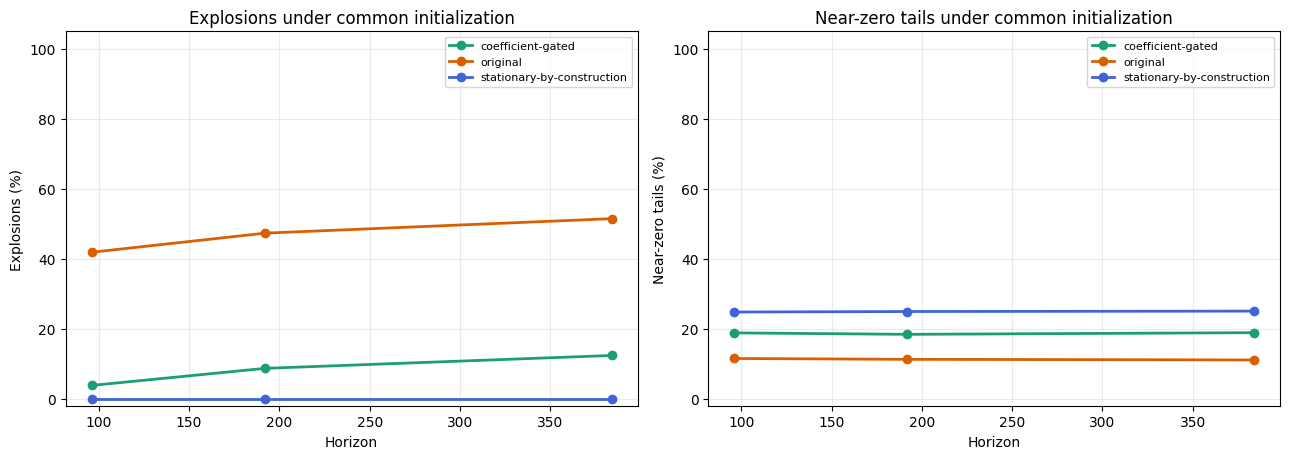

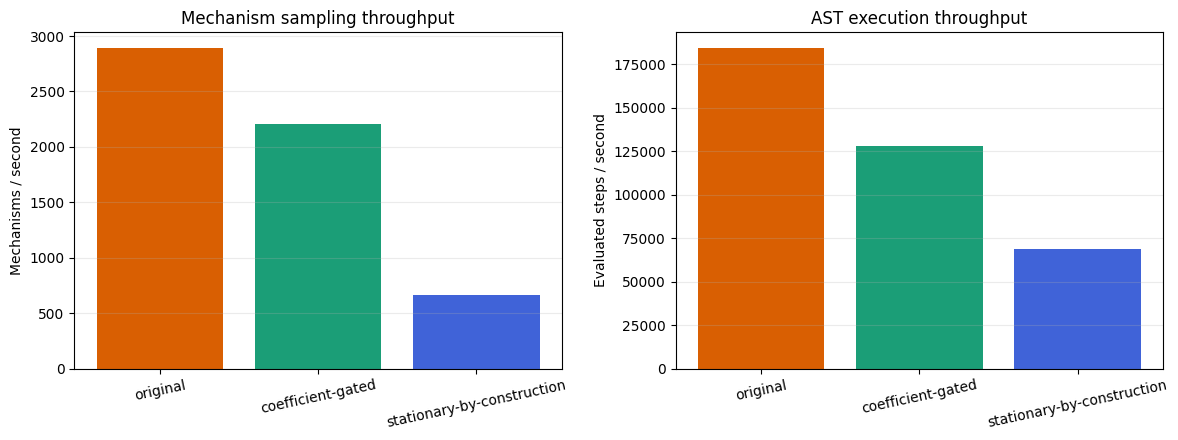

In [5]:
colors = {
    'original': '#d95f02',
    'coefficient-gated': '#1b9e77',
    'stationary-by-construction': '#4063d8',
}
common = summary[summary['protocol'].eq('common-zero-initialization')]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
for method, group in common.groupby('method'):
    group = group.sort_values('horizon')
    axes[0].plot(group['horizon'], 100 * group['explosion_rate'],
                 marker='o', linewidth=2, color=colors[method], label=method)
    axes[1].plot(group['horizon'], 100 * group['near_zero_rate'],
                 marker='o', linewidth=2, color=colors[method], label=method)
axes[0].set(title='Explosions under common initialization',
            xlabel='Horizon', ylabel='Explosions (%)', ylim=(-2, 105))
axes[1].set(title='Near-zero tails under common initialization',
            xlabel='Horizon', ylabel='Near-zero tails (%)', ylim=(-2, 105))
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
fig.tight_layout()
plt.show()

common_performance = performance[
    performance['protocol'].eq('common-zero-initialization')
].set_index('method')
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(common_performance.index,
            common_performance['sampled_mechanisms_per_second'],
            color=[colors[name] for name in common_performance.index])
axes[1].bar(common_performance.index,
            common_performance['evaluated_steps_per_second'],
            color=[colors[name] for name in common_performance.index])
axes[0].set(title='Mechanism sampling throughput', ylabel='Mechanisms / second')
axes[1].set(title='AST execution throughput', ylabel='Evaluated steps / second')
for axis in axes:
    axis.tick_params(axis='x', rotation=12)
    axis.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

**O que foi feito.** Os primeiros painéis mostram como as classificações mudam com o horizonte. Os painéis de desempenho separam o custo de construir mecanismos do custo de executar seus nós AST; mecanismos que explodem cedo avaliam menos passos, razão pela qual `evaluated_steps_per_second` deve ser lido junto da taxa de sucesso até 384 passos. A amostragem estacionária inclui conversão PACF, certificado de raízes e solução da covariância de Lyapunov, enquanto a amostragem das outras duas linhas constrói somente a AST e seus bindings.

## 6. Interpretação

`coefficient-gated` é uma intervenção local na gramática original: reduz ganhos unitários implícitos, mas a soma dos ganhos e os produtos entre lags continuam sem restrição global. `stationary-by-construction` muda a família para uma recorrência AR linear cujas raízes são verificadas antes da simulação. Essa garantia implica uma distribuição estacionária quando combinada com a inicialização calculada e as inovações especificadas. Ela não afirma que uma variável gaussiana seja limitada; por isso o teste empírico de módulo 100 continua informativo como verificação numérica, embora não seja a fonte da garantia.

A métrica `near_zero` também não significa convergência assintótica. Com inovações em todos os passos, um processo estacionário preserva variância. O rótulo informa apenas que uma janela finita ficou dentro de três desvios-padrão da inovação.

## Registro completo do experimento

A célula seguinte é o registro autocontido do experimento executado.

In [6]:
def git_output(*arguments: str) -> str | None:
    try:
        return subprocess.check_output(
            ['git', *arguments], cwd=PROJECT_ROOT, text=True,
            stderr=subprocess.DEVNULL,
        ).strip()
    except (subprocess.CalledProcessError, FileNotFoundError):
        return None


def json_records(frame: pd.DataFrame) -> list[dict]:
    return json.loads(frame.to_json(orient='records'))


main_index = main_reference.set_index('method')
experiment_record = {
    'experiment_id': 'abstract_syntax_tree_stationarity_002_three_method_tradeoff',
    'status': 'executed',
    'research_question': (
        'How do the original AST, coefficient-gated AST, and stationary AR generator compare '
        'in finite-horizon explosion, near-zero behavior, and generation throughput?'
    ),
    'configuration': configuration,
    'seed_policy': {
        'mechanism_seed': 'derive_sample_seed(ROOT_SEED, sample_index)',
        'innovation_seed': 'second child of SeedSequence([ROOT_SEED, sample_index, 991]).spawn(2)',
        'stationary_initialization_seed': 'SeedSequence([ROOT_SEED, sample_index, 992])',
        'same_innovation_per_sample_index_across_methods': True,
        'external_global_rng_used': False,
    },
    'provenance': {
        'implementation': [
            'src/tsfmxai/generators/random_expression.py',
            'src/tsfmxai/generators/stationary.py',
            'src/tsfmxai/generators/trajectory.py',
            'src/tsfmxai/evaluation/stability.py',
        ],
        'project_head': git_output('rev-parse', 'HEAD'),
        'python': sys.version, 'platform': platform.platform(),
        'packages': {name: importlib.metadata.version(name)
                     for name in ['numpy', 'pandas', 'matplotlib']},
    },
    'metrics': {
        'outcomes': json_records(summary),
        'generation_performance': json_records(performance),
        'complete_comparison_table': json_records(complete_table),
        'stationarity_certificate': certificate_summary['value'].to_dict(),
    },
    'scientific_summary': (
        f"At horizon {REFERENCE_HORIZON} with zero initialization, explosion rates were "
        f"{main_index.loc['original', 'explosion_rate']:.2%} (original), "
        f"{main_index.loc['coefficient-gated', 'explosion_rate']:.2%} (coefficient-gated), and "
        f"{main_index.loc['stationary-by-construction', 'explosion_rate']:.2%} "
        '(stationary by construction). The stationary result is additionally supported by a '
        'positive analytic root-condition margin for every sampled mechanism.'
    ),
    'limitations': [
        'The stationary implementation is a linear AR family, whereas the two random AST families may contain lag products.',
        'The common zero initialization is controlled but is not stationary initialization for the AR family.',
        'A stationary Gaussian process is unbounded in support, so stationarity does not logically prohibit a finite threshold exceedance.',
        'Near-zero tails are a finite-window diagnostic and not proof of asymptotic convergence.',
        'Stationary mechanism sampling includes certification and covariance computation, unlike the two AST-only samplers.',
        'Runtime was measured in one notebook execution and depends on hardware and early stopping.',
    ],
    'reproduction_command': (
        r'.\.venv\Scripts\python.exe -m jupyter nbconvert --to notebook --execute --inplace '
        r'experiments\abstract_syntax_tree\stationarity_by_construction\02_three_method_stability_tradeoff.ipynb '
        r'--ExecutePreprocessor.timeout=2400'
    ),
}
print(json.dumps(experiment_record, indent=2, ensure_ascii=False))

{
  "experiment_id": "abstract_syntax_tree_stationarity_002_three_method_tradeoff",
  "status": "executed",
  "research_question": "How do the original AST, coefficient-gated AST, and stationary AR generator compare in finite-horizon explosion, near-zero behavior, and generation throughput?",
  "configuration": {
    "root_seed": 20261001,
    "sample_count_per_method": 5000,
    "horizons": [
      96,
      192,
      384
    ],
    "reference_horizon": 192,
    "innovation_std": 0.05,
    "explosion_limit": 100.0,
    "near_zero_radius": 0.15000000000000002,
    "near_zero_tail_steps": 24,
    "baseline_tree_config": {
      "minimum_operators": 1,
      "maximum_operators": 6,
      "num_series": 1,
      "minimum_lag": 1,
      "maximum_lag": 12,
      "parameter_probability": 0.55,
      "time_probability": 0.0,
      "lag_probability": 0.45,
      "add_probability": 0.8,
      "minimum_parameter_magnitude": 0.05,
      "maximum_parameter_magnitude": 0.8,
      "require_lag": tru

**O que foi feito.** Esta célula única registra pergunta, configuração completa, política de sementes, proveniência, métricas, limitações, síntese científica e comando de reprodução. Nenhum sidecar é necessário.